In [3]:
import pandas as pd
import numpy as np

# EDA

In [4]:
df = pd.read_csv('/content/car_price.csv')

In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [6]:
df.shape

(72435, 10)

In [7]:
df.dtypes

,0
model,object
year,float64
price,float64
transmission,object
mileage,float64
fuelType,object
tax,float64
mpg,float64
engineSize,float64
Make,object


In [8]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

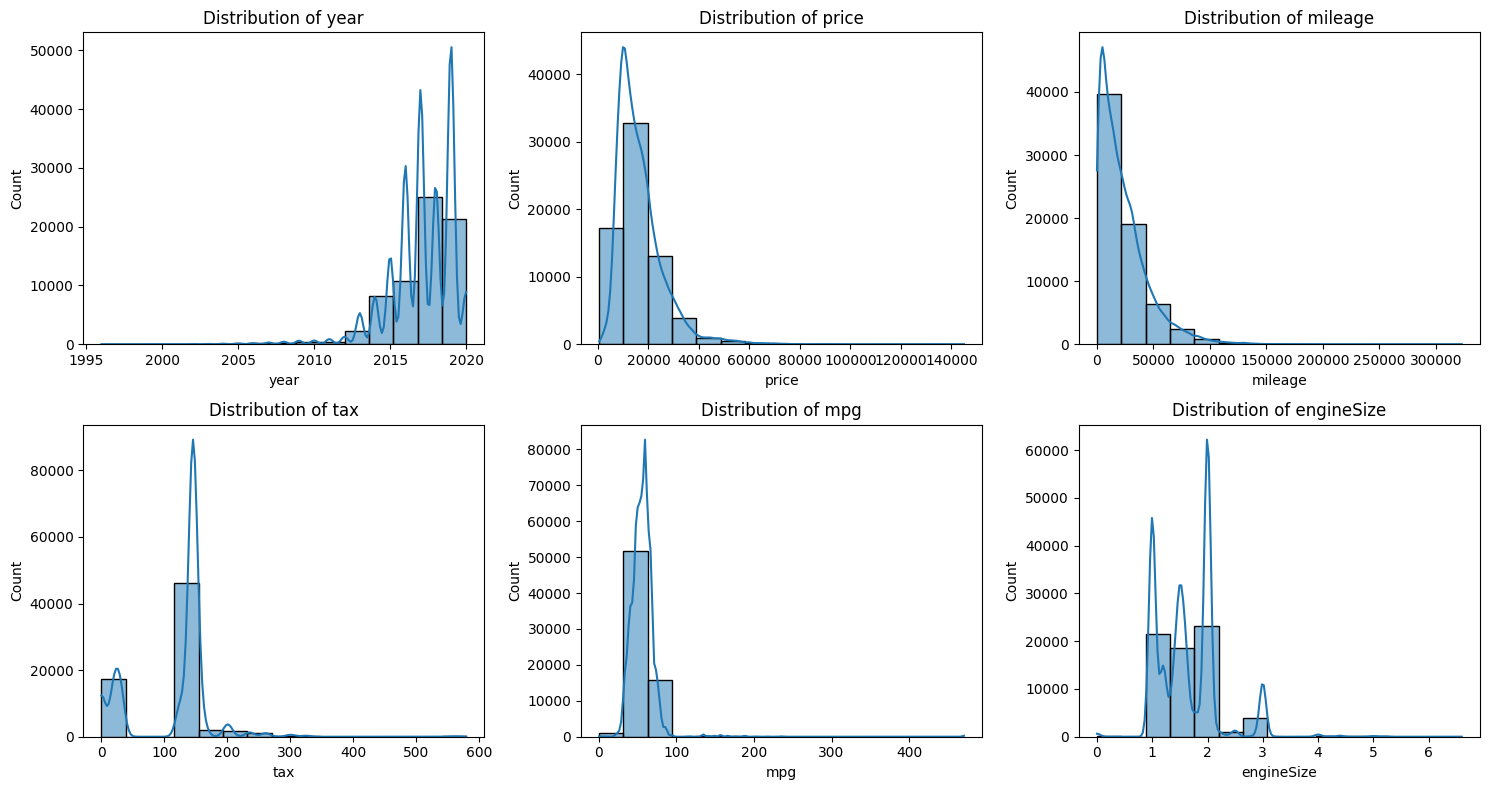

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = numeric_cols.columns
n = len(cols)

cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, bins=15, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: >

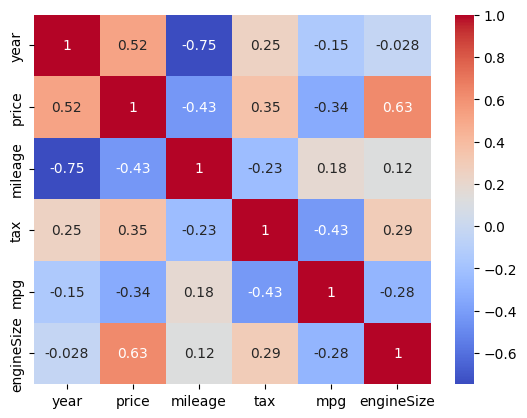

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# Preprocessing

In [11]:
df.isnull().sum()

,0
model,3621
year,3622
price,3621
transmission,3623
mileage,3622
fuelType,3622
tax,3621
mpg,3621
engineSize,3622
Make,3621


In [12]:
# Feature engineering

df['Car Age'] = 2026 - df['year']

def engine_group(x):
    if x < 1.6:
        return 'Small'
    elif x < 2.5:
        return 'Medium'
    else:
        return 'Large'


df['Engine Category'] = df['engineSize'].apply(engine_group)
df = df.drop(columns=['engineSize', 'year'])


In [13]:
df_reg = df.dropna(subset=['price'])
df_reg = df_reg.drop(columns=['Make'])
X_reg = df_reg.drop('price', axis=1)
y_reg = df_reg['price']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            68814 non-null  object 
 1   price            68814 non-null  float64
 2   transmission     68812 non-null  object 
 3   mileage          68813 non-null  float64
 4   fuelType         68813 non-null  object 
 5   tax              68814 non-null  float64
 6   mpg              68814 non-null  float64
 7   Make             68814 non-null  object 
 8   Car Age          68813 non-null  float64
 9   Engine Category  72435 non-null  object 
dtypes: float64(5), object(5)
memory usage: 5.5+ MB


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler())

engine_categories = [['Small', 'Medium', 'Large']]
engine_pipline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=engine_categories)
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_pipeline, ['mileage']),
        ('num', numeric_transformer, ['tax','mpg','Car Age']),
        ('cat', categorical_transformer, ['model','transmission','fuelType']),
        ('engine', engine_pipline, ['Engine Category'])
    ]
)


# Regression Model

In [16]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('regressor', LinearRegression())
])

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2,random_state=42 )

In [18]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['mileage']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['model', 'transmission',
                                                   'fuelType']),
                                                 ('engine',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'Large']]))]),
                                                  ['Engine Category'])])),
                ('regressor', LinearRegression())])

In [19]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_reg, y_reg, cv=kf)

print(f"R2 Scores: {scores}")
print(f"Average R2: {scores.mean():.4f}")

R2 Scores: [0.83165002 0.8338897  0.84019563 0.82964255 0.83864244]
Average R2: 0.8348


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2477.309140907676
RMSE: 3784.9062082573405
R2 Score: 0.8316500158040074


# Predicted vs Actual (Regression Plot)

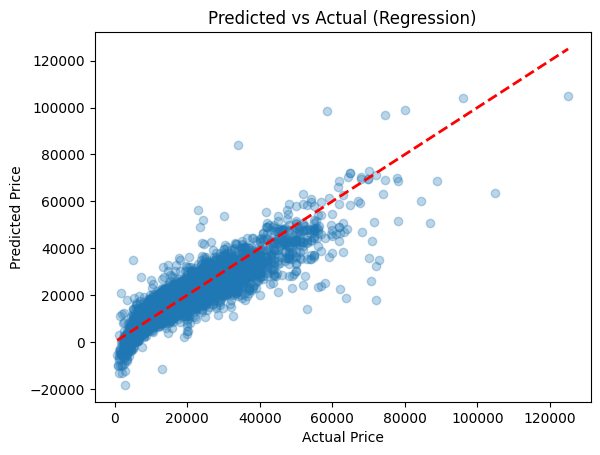

In [23]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual (Regression)')
plt.show()

# Task 3: Create Target Variables (Classification)

We define price thresholds based on quantiles (33% and 66%).
This ensures a balanced distribution across categories.


In [21]:
q1 = df['price'].quantile(0.33)
q2 = df['price'].quantile(0.66)
print(f"Thresholds: Cheap < {q1:.2f}, Moderate {q1:.2f} - {q2:.2f}, Expensive > {q2:.2f}")

def classify_price(price):
    if price < q1:
        return 'Cheap'
    elif price <= q2:
        return 'Moderate'
    else:
        return 'Expensive'

df['price_category'] = df['price'].apply(classify_price)


Thresholds: Cheap < 11450.00, Moderate 11450.00 - 17995.00, Expensive > 17995.00


# Task 5: KNN Classification


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 472, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 1199, in score
    return self.steps[-1][1].score(Xt, y, **score_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py", line 446, in score
    return super().score(X, 

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5}
              precision    recall  f1-score   support

       Cheap       0.78      0.90      0.83      4592
   Expensive       0.90      0.76      0.83      5391
    Moderate       0.71      0.73      0.72      4504

    accuracy                           0.79     14487
   macro avg       0.79      0.79      0.79     14487
weighted avg       0.80      0.79      0.79     14487



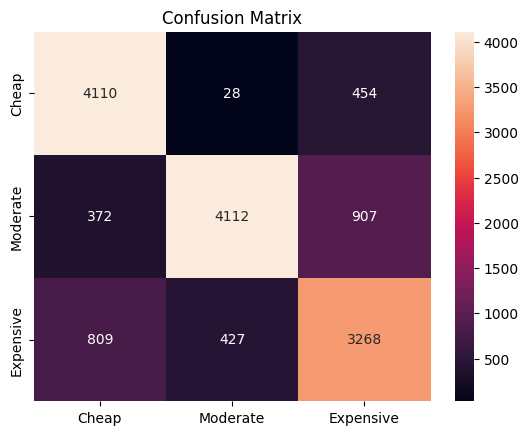

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for classification
df_class = df.dropna(subset=['price_category'])
X_class = df_class.drop(columns=['price', 'price_category', 'Make'])
y_class = df_class['price_category']

# Preprocessing for classification (using existing preprocessor structure)
# We can re-use the regression preprocessor for consistency as requested
knn_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('knn', KNeighborsClassifier())
])

# Grid Search
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__metric': ['euclidean', 'manhattan']
}

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

grid_search = GridSearchCV(knn_pipeline, param_grid, cv=3, verbose=1)
grid_search.fit(X_train_c, y_train_c)

print("Best Parameters:", grid_search.best_params_)
y_pred_c = grid_search.predict(X_test_c)

print(classification_report(y_test_c, y_pred_c))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Cheap', 'Moderate', 'Expensive'], yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix')
plt.show()
